# Case Study
- **Goal**: A farmer seeks a predictive model to determine whether the paddy yield per hectare for a given agriblock (a defined unit of agricultural land) exceeds the mean paddy yield per hectare

In [46]:
# Essential packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [2]:
file_name = 'Asm1_dataset26.csv'
df = pd.read_csv(file_name)
df.head(5)

,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,...,Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
0,6,Cuddalore,CO_43,alluvial,150,75.0,dry,120,6,240,...,SW,W,NNW,WSW,72.0,78,88,85,540,35028
1,6,Kurinjipadi,ponmani,clay,150,75.0,wet,120,6,240,...,NW,S,SE,SSE,64.6,85,84,87,600,35412
2,6,Panruti,delux ponni,alluvial,150,75.0,dry,120,6,240,...,ENE,NE,NNE,W,85.0,96,84,79,600,36300
3,6,Kallakurichi,CO_43,clay,150,75.0,wet,120,6,240,...,--,WNW,SE,S,88.5,95,81,84,540,35016
4,6,Sankarapuram,ponmani,alluvial,150,75.0,dry,120,6,240,...,SSE,W,SW,NW,72.7,91,83,81,600,34044


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2789 entries, 0 to 2788
Data columns (total 45 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Hectares                            2789 non-null   int64  
 1   Agriblock                           2789 non-null   object 
 2   Variety                             2789 non-null   object 
 3   Soil Types                          2789 non-null   object 
 4   Seedrate(in Kg)                     2789 non-null   int64  
 5   LP_Mainfield(in Tonnes)             2789 non-null   float64
 6   Nursery                             2789 non-null   object 
 7   Nursery area (Cents)                2789 non-null   int64  
 8   LP_nurseryarea(in Tonnes)           2789 non-null   int64  
 9   DAP_20days                          2789 non-null   int64  
 10  Weed28D_thiobencarb                 2789 non-null   int64  
 11  Urea_40Days                         2789 no

## Task 1. Data Preparation
* What variables are included in the modelling, their roles and measurement level set and why?
* Any data issues addressed? Describe the step to transform/clean the data
* Create a new binary column named 'isAboveAvg' as the target variable, where the value is set to 1 if the paddy field per hectare exceeds the mean paddy yield per hectare, and 0 otherwise. Reorganize the dataset by removing potentially noisy or non-informative columns, such as Hectares, Paddy Yield, etc.
* Identify and remove highly correlated columns with a pairwise correlation coefficient greater than 0.98

In [3]:
# Cleaning the data
df.columns = df.columns.str.strip() # Column Hectares has a redundant space
print(f'Original dataset: {df.shape}')

# Identify duplicated rows
print(f'Number of duplicated rows: {df.duplicated().sum()}')

# Remove duplicated rows
df = df.drop_duplicates(keep='first')
print(f'Cleaned dataset: {df.shape}')


Original dataset: (2789, 45)
Number of duplicated rows: 161
Cleaned dataset: (2628, 45)


In [4]:
# Identify missing values
missing_value = df.isnull().sum()
print(f'Missing values per columns:\n{missing_value[missing_value > 0]}')

Missing values per columns:
Min temp_D1_D30      107
Min temp_D31_D60     107
Min temp_D61_D90     107
Min temp_D91_D120    107
dtype: int64


In [5]:
# Impute missing values with its median
cols = ['Min temp_D1_D30', 'Min temp_D31_D60', 'Min temp_D61_D90', 'Min temp_D91_D120']
for col in cols:
    df[col] = df[col].fillna(df[col].median())
    print(col, df[col].unique().tolist())

# Replace '--' with NA in categorical variables
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].replace('--', 'NA')
    print(col, df[col].unique().tolist())

Min temp_D1_D30 [18.5, 19.5, 20.0, 19.0, 20.5, 18.0]
Min temp_D31_D60 [16.0, 18.5, 18.0, 17.0, 17.5, 15.5]
Min temp_D61_D90 [15.5, 17.0, 17.5, 16.5, 18.0, 15.0]
Min temp_D91_D120 [16.0, 18.0, 15.5, 16.5, 15.0]
Agriblock ['Cuddalore', 'Kurinjipadi', 'Panruti', 'Kallakurichi', 'Sankarapuram', 'Chinnasalem']
Variety ['CO_43', 'ponmani', 'delux ponni']
Soil Types ['alluvial', 'clay']
Nursery ['dry', 'wet']
Wind Direction_D1_D30 ['SW', 'NW', 'ENE', 'NA', 'SSE', 'E', 'W']
Wind Direction_D31_D60 ['W', 'S', 'NE', 'WNW', 'ENE', 'NA']
Wind Direction_D61_D90 ['NNW', 'SE', 'NNE', 'SW', 'NE', 'NA']
Wind Direction_D91_D120 ['WSW', 'SSE', 'W', 'S', 'NW', 'NNW', 'NA']


In [6]:
# Calculate the mean of the paddy yield per hectares
df['yield_per_hec'] = df['Paddy yield(in Kg)']/df['Hectares'] 
mean_yield = df['yield_per_hec'].mean()
print(f'Mean yield per hec: {mean_yield:.2f}')

# Create a column name 'isAboveAvg'
df['isAboveAvg'] = np.where(df['yield_per_hec'] > mean_yield, 1, 0)
df['isAboveAvg'].value_counts()

Mean yield per hec: 5990.15


isAboveAvg
0    1327
1    1301
Name: count, dtype: int64

In [7]:
# Drop noisy columns
drop_cols = ['Hectares', 'Paddy yield(in Kg)', 'yield_per_hec', 'Trash(in bundles)']
df_clean = df.drop(columns = drop_cols)
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2628 entries, 0 to 2788
Data columns (total 43 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Agriblock                           2628 non-null   object 
 1   Variety                             2628 non-null   object 
 2   Soil Types                          2628 non-null   object 
 3   Seedrate(in Kg)                     2628 non-null   int64  
 4   LP_Mainfield(in Tonnes)             2628 non-null   float64
 5   Nursery                             2628 non-null   object 
 6   Nursery area (Cents)                2628 non-null   int64  
 7   LP_nurseryarea(in Tonnes)           2628 non-null   int64  
 8   DAP_20days                          2628 non-null   int64  
 9   Weed28D_thiobencarb                 2628 non-null   int64  
 10  Urea_40Days                         2628 non-null   float64
 11  Potassh_50Days                      2628 non-nul

In [8]:
# Correlation Analysis
## Encode categorical columns with One-hot encoding
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

# Separate input and target variables
X = df_encoded.drop(columns=['isAboveAvg'])
y = df_encoded['isAboveAvg']

corr_matrix = X.corr().abs()

# Find highly correlated pair-wise columns
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.98)]

# Drop highly correlated columns
df_final = X.drop(columns=high_corr_cols)

print(f'There are {len(high_corr_cols)} highly correlated columns')
print(f'Highly correlated columns to drop:\n{"\n".join(high_corr_cols)}')

There are 15 highly correlated columns
Highly correlated columns to drop:
LP_Mainfield(in Tonnes)
Nursery area (Cents)
LP_nurseryarea(in Tonnes)
DAP_20days
Weed28D_thiobencarb
Urea_40Days
Potassh_50Days
Micronutrients_70Days
Pest_60Day(in ml)
30DAI(in mm)
30_50DAI(in mm)
51_70AI(in mm)
71_105DRain(in mm)
71_105DAI(in mm)
Min temp_D61_D90


## Task 2. Decision Tree modelling (4 marks)
* Build a decision tree using the default setting, examine the tree results and answer the questions:
    * What parameters have been used to build the tree? Detail them
    * What data split was used to create training and test datasets?
    * What is the classification accuracy on the training and test datasets?
    * What is the size of the tree (number of nodes and rules)?
    * Which variables is used for the first split? What are the variables that are used for the second split?
    * What are the 10 important variables in build the tree?
* Build another decision tree tuned with GridSearchCV. Examine the result:
    * What are the optimal parameters for this decision tree? Explain your choice of hyperparameters to search, and the chosen search range(s)?
    * What is the classification accuracy on the training the test datasets?
    * What is the size of the chosen tree (number of nodes and rules)?
    * Which variable is used for the first split? What are the variables that are used for the 2nd split?
    * What are the 10 important variables in building the tree?
    * Report which decision tree model exhibits significant evidence of overfitting 
* What is the significant difference between these 2 decision tree models? Visualize the trees and list some of the rules where the class is positive (target variable = 1)
* Produce the ROC curve for both decision tree models. Compare the performance of the 2 models and analyze the key variables (features) they utilize

### 2.1. Decision Tree with default setting

In [9]:
X_train, X_test, y_train, y_test = train_test_split(df_final, y, random_state=42)

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Q1. What parameters have been used to build the tree?

In [10]:
for p, v in clf.get_params().items():
    print(f'{p}: {v}')

ccp_alpha: 0.0
class_weight: None
criterion: gini
max_depth: None
max_features: None
max_leaf_nodes: None
min_impurity_decrease: 0.0
min_samples_leaf: 1
min_samples_split: 2
min_weight_fraction_leaf: 0.0
monotonic_cst: None
random_state: 42
splitter: best


Q2. What data split was used to create training and test datasets?

In [11]:
train_size = (len(X_train) / len(df_final)) * 100
test_size = 100 - train_size
print(f'Train size: {train_size:.2f}%')
print(f'Test size: {test_size:.2f}%')

Train size: 75.00%
Test size: 25.00%


Q3. What is the classification accuracy on the training and test datatset?

In [12]:
train_acc = accuracy_score(y_train, clf.predict(X_train)) * 100
test_acc = accuracy_score(y_test, clf.predict(X_test)) * 100
print(f'Training accuracy: {train_acc:.2f}%\nTest accuracy: {test_acc:.2f}%')

Training accuracy: 93.25%
Test accuracy: 86.91%


Q4. What is the size of the tree (number of nodes and rules)?

In [13]:
print(f'Total nodes: {clf.tree_.node_count} nodes')
print(f'Rules: {clf.tree_.n_leaves} leaves')

Total nodes: 581 nodes
Rules: 291 leaves


Q5. Which variable is used for the first split? What are the variables that are used for the second split?

In [14]:
tree = clf.tree_
feature_names = X_train.columns
first_feature = feature_names[tree.feature[0]]
left_child = tree.children_left[0]
right_child = tree.children_right[0]
print(f'First split: {first_feature}')
print(f'Second split:')
print(f'Left: {feature_names[tree.feature[left_child]]}')
print(f'Right: {feature_names[tree.feature[right_child]]}')

First split: Seedrate(in Kg)
Second split:
Left: Wind Direction_D61_D90_SW
Right: Seedrate(in Kg)


Q6. What are the 10 important features in building the tree?

In [15]:
important_features = pd.DataFrame({'Feature': feature_names, 'Importance': clf.feature_importances_})
important_features.sort_values(by='Importance', ascending=False).head(10)

,Feature,Importance
0,Seedrate(in Kg),0.808279
24,Variety_delux ponni,0.042062
26,Soil Types_clay,0.032533
27,Nursery_wet,0.022675
25,Variety_ponmani,0.015571
7,Max temp_D31_D60,0.007685
6,Min temp_D31_D60,0.006056
8,Max temp_D61_D90,0.005730
34,Wind Direction_D31_D60_NA,0.005434
37,Wind Direction_D31_D60_W,0.004992


### 2.2. Decision tree tuned with GridSearchCV

2.2.a. What are the optimal parameters for this decision tree? Explain your choice of hyperparameters to search, and the chosen search range(s)?

In [16]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 5, 7, 10, 12],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10]
}

dt = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_clf = grid_search.best_estimator_
print(f'Optimal Parameters:\n{grid_search.best_params_}')

Optimal Parameters:
{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 20}


Reasoning:
- 'gini' and 'entropy' are the 2 standard impurity metrics and there are no other metrics
- 'max_depth':
    + 'None' to see if the other constrains (e.g. min_samples_*) could fix the tree on their own
    + [3, 5, 7, 10] are the standard and small range to immediately avoid overfit
    + 15: (about 2^15 ~ 32k leaves) is the maximum possible meaningful threshold for this metric as we only have ~1952 rows in the df
- 'min_samples_split' & 'min_samples_leaf': we use the recommend default range searched on the internet

2.2.b. What is the classification accuracy on the training and test datasets?

In [17]:
train_acc = accuracy_score(y_train, best_clf.predict(X_train)) * 100
test_acc = accuracy_score(y_test, best_clf.predict(X_test)) * 100
print(f'Training accuracy: {train_acc:.2f}%')
print(f'Test accuracy: {test_acc:.2f}%')

Training accuracy: 90.36%
Test accuracy: 91.63%


2.2.b. What is the size of the chosen tree (number of nodes and rules)?

In [18]:
print(f'Number of nodes: {best_clf.tree_.node_count} nodes')
print(f'Number of rules: {best_clf.tree_.n_leaves} leaves')

Number of nodes: 41 nodes
Number of rules: 21 leaves


2.2.c. What variable is used for the first split? What are the variables that are used for the second split?

In [19]:
tree = best_clf.tree_
feature_names = X_train.columns
first_feature = feature_names[tree.feature[0]]
left_child = tree.children_left[0]
right_child = tree.children_right[0]
print(f'First split: {first_feature}')
print(f'Second split:')
print(f'Left: {feature_names[tree.feature[left_child]]}')
print(f'Right: {feature_names[tree.feature[right_child]]}')

First split: Seedrate(in Kg)
Second split:
Left: Wind Direction_D61_D90_SW
Right: Seedrate(in Kg)


2.2.d. What are the 10 important variables in building a tree?

In [20]:
important_features = pd.DataFrame({'Feature': feature_names, 'Importance': best_clf.feature_importances_})
important_features.sort_values(by='Importance', ascending=False).head(10)

,Feature,Importance
0,Seedrate(in Kg),0.942228
24,Variety_delux ponni,0.037526
25,Variety_ponmani,0.006987
10,Max temp_D91_D120,0.004433
30,Wind Direction_D1_D30_NW,0.002352
8,Max temp_D61_D90,0.001903
26,Soil Types_clay,0.001503
15,Relative Humidity_D1_D30,0.001497
29,Wind Direction_D1_D30_NA,0.000764
27,Nursery_wet,0.000667


2.2.e. Report which decision tree model exhibits significant evidence of overfitting

The default decision tree exhibits significant evidence of overfitting as the accuracy gap between the training (93.25%) and test (86.91%) is high. Whereas, in the second tuned tree using GridSearchCV, the gap is smaller with training accuracy and test accuracy are 90.36% and 91.63% respectively.

Furthermore, the first tree created 261 hyper-specific rules (leaves) to perfectly categorize the training data. The second tree achieved a better accuracy using only 21 rules.

## Task 3. Regression Modeling
1. Describe which regression model was selected for the classification problem and what additional processing was required on this dataset to be used in regression modelling. List the variables that need further processing and provide detail of the processing.
2. Build a regression model tuned with GridSearchCV. Answer the following:
    - a. Name the Regression function used
    - b. What are the optimal parameters for this regression model? Explain your choice of hyperparameters to search, and the chosen search range(s)?
    - c. Report the variables that are included in the regression model.
    - d. Report the top-10 important variables (in order) in the model
    - e. What is the classification accuracy on training and test datasets?
3. Build another regression model on the reduced variables set. To minimise variables, either perform dimensionality reduction with Recursive Feature Elimination or select a subset of inputs found significant by the decision tree (use the best decision tree model under Task 2). Tune the model with GridSearchCV to find the best parameter setting. Answer the following;
    - a. Was dimensionality reduction helpful in identifying a good feature set for building the accurate model? Report the feature selection method used.
    - b. Report the variables that are included in the regression model.
    - c. What is the classification accuracy on the training and test datasets?
    - d. Report which regression model exhibits significant evidence of overfitting.
4. Produce the ROC curve for both regression models. Compare the performance of the 2 models and analyze the key variables (features) they utilize.

3.1. Which regression model was selected and list of variables that need further processing
- As the output of the classification is binary ('isAboveAvg' as 0 and 1), the model should be used is Logistic Regression. As the previous method, Decision Tree, does not care about the scale of the data, we need additional processing. Logistic Regression, on the other hand, is sensitive to the data scale. For example, if 1 variable is measure in thousands, and another in decimals, the model will struggle to find the right weights. That's why feature scaling is needed for this step.
- Variables that need further processing including all continuous or numeric predictors, which are:
    + Seedrate (in Kg)
    + 30Drain (in mm)
    + 30_50Drain (in mm)
    + Min temp_D1_D30, Max temp_D1_D30
    + Min temp_D31_D60, Max temp_D31_D60
    + Max temp_D61_D90
    + Min temp_D91_D120, Max temp_D91_D120
    + Inst Wind Speed_D1_D30(in Knots) -> D91_D120
    + Relative Humidity_D1_D30 -> D91_D120
- Processing:

In [21]:
from sklearn.preprocessing import StandardScaler

In [ ]:
binary_cols = [col for col in df_final.columns if df_final[col].nunique() == 2]
continuous_cols = [col for col in df_final.columns if col not in binary_cols]

scaler = StandardScaler()
df_scaled = df_final.copy()

# Fit and transform continous/numeric columns
df_scaled[continuous_cols] = scaler.fit_transform(df_final[continuous_cols])

print("\nBefore Scaling (Mean & Variance of Seedrate):")
print(f"Mean: {df_final['Seedrate(in Kg)'].mean():.2f}, Variance: {df_final['Seedrate(in Kg)'].var():.2f}")

print("\nAfter Scaling (Mean & Variance of Seedrate):")
print(f"Mean: {df_scaled['Seedrate(in Kg)'].mean():.2f}, Variance: {df_scaled['Seedrate(in Kg)'].var():.2f}")

Number of continuous variables to scale: 19
Number of binary variables to leave alone: 31

Before Scaling (Mean & Variance of Seedrate):
Mean: 93.01, Variance: 1308.39

After Scaling (Mean & Variance of Seedrate):
Mean: 0.00, Variance: 1.00


3.2. Regression Model tuned with GridSearchCV

In [26]:
from sklearn.linear_model import LogisticRegression

In [28]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols] = scaler.fit_transform(X_test[continuous_cols])

lr = LogisticRegression(max_iter=5000, random_state=42)

grid_search = GridSearchCV(lr, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

best_lr = grid_search.best_estimator_
print(f"Optimal Parameters: {grid_search.best_params_}")

Optimal Parameters: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}


3.2.a. Regression function used is Logistic Regression

3.2.b. Optimal params: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}
- penalty ('l1', 'l2'): this tests 2 different types of penalties to prevent overfitting. We test both to see which fits the data better. And the result suggests 'l1'
- C: this controls how strong the penalty is. We chose this scale because it is standard to test magnitudes of 10 to find the general optimal score
- solver ('liblinear', 'saga'): We chose these 2 solvers because they can evaluate both l1 and l2 penalties on this dataset

3.2.c. 50 independent variables were fed into the Logistic Regression model, including all dummy-encoded categorical variables and the scaled continous variables
...

3.2.d. Top 10 important variables

In [29]:
coefs = best_lr.coef_[0]

important_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': coefs,
    'Absolute_Importance': np.abs(coefs),
})

top_10 = important_df.sort_values(by='Absolute_Importance', ascending=False).head(10)
print('Top 10 important variables:')
print(top_10.to_string(index=False))

Top 10 important variables:
           Feature  Coefficient  Absolute_Importance
   Seedrate(in Kg)     1.646204             1.646204
   30DRain( in mm)     0.000000             0.000000
30_50DRain( in mm)     0.000000             0.000000
 51_70DRain(in mm)     0.000000             0.000000
   Min temp_D1_D30     0.000000             0.000000
   Max temp_D1_D30     0.000000             0.000000
  Min temp_D31_D60     0.000000             0.000000
  Max temp_D31_D60     0.000000             0.000000
  Max temp_D61_D90     0.000000             0.000000
 Min temp_D91_D120     0.000000             0.000000


3.2.e. Accuracy

In [31]:
train_acc = accuracy_score(y_train, best_lr.predict(X_train_scaled))
test_acc = accuracy_score(y_test, best_lr.predict(X_test_scaled))
print(f'Train ACC: {train_acc * 100:.2f}%; \nTest ACC: {test_acc * 100:.2f}%')

Train ACC: 88.94%; 
Test ACC: 90.72%


3.3. Regression Model on reduced variables set

3.3.a, b. Dimensionality Reduction and Feature Selection

In [ ]:
dt = DecisionTreeClassifier(criterion='gini', max_depth=5, min_samples_leaf=5, min_samples_split=20, random_state=42)
dt.fit(X_train, y_train)

importance = dt.feature_importances_
important_features = X_train.columns[importance > 0].tolist()
print(f'Number of selected features: {len(important_features)}')

for idx, feature in enumerate(important_features):
    print(idx+1, feature)

X_train_sub = X_train_scaled[important_features]
X_test_sub = X_test_scaled[important_features]

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

lr_reduced = LogisticRegression(max_iter=5000, random_state=42)
grid_search_reduced = GridSearchCV(lr_reduced, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_reduced.fit(X_train_sub, y_train)

best_lr_reduced = grid_search_reduced.best_estimator_
print(f'Optimal params: {grid_search_reduced.best_params_}')

Number of selected features: 12
1 Seedrate(in Kg)
2 Max temp_D61_D90
3 Max temp_D91_D120
4 Inst Wind Speed_D1_D30(in Knots)
5 Relative Humidity_D1_D30
6 Variety_delux ponni
7 Variety_ponmani
8 Soil Types_clay
9 Nursery_wet
10 Wind Direction_D1_D30_NA
11 Wind Direction_D1_D30_NW
12 Wind Direction_D61_D90_SW
Optimal params: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}


Dimensional reduction helps reduce from 50 variables down to only 12.

3.3.c Accuracy

In [43]:
train_acc = accuracy_score(y_train, best_lr_reduced.predict(X_train_sub))
test_acc = accuracy_score(y_test, best_lr_reduced.predict(X_test_sub))
print(f'Train ACC: {train_acc*100:.2f}% \nTest ACC: {test_acc*100:.2f}%')

Train ACC: 88.94% 
Test ACC: 90.72%


3.3.d. Overfitting
- Neither of the Logistic Regression models in Task 5 or 6 exibhit significant evidence of overfitting. They demonstrate excellent generalization as their test accuracy (90.72%) is actually higher than their training accuracy (88.94%).

3.4. ROC Curve

In [44]:
from sklearn.metrics import roc_curve, auc

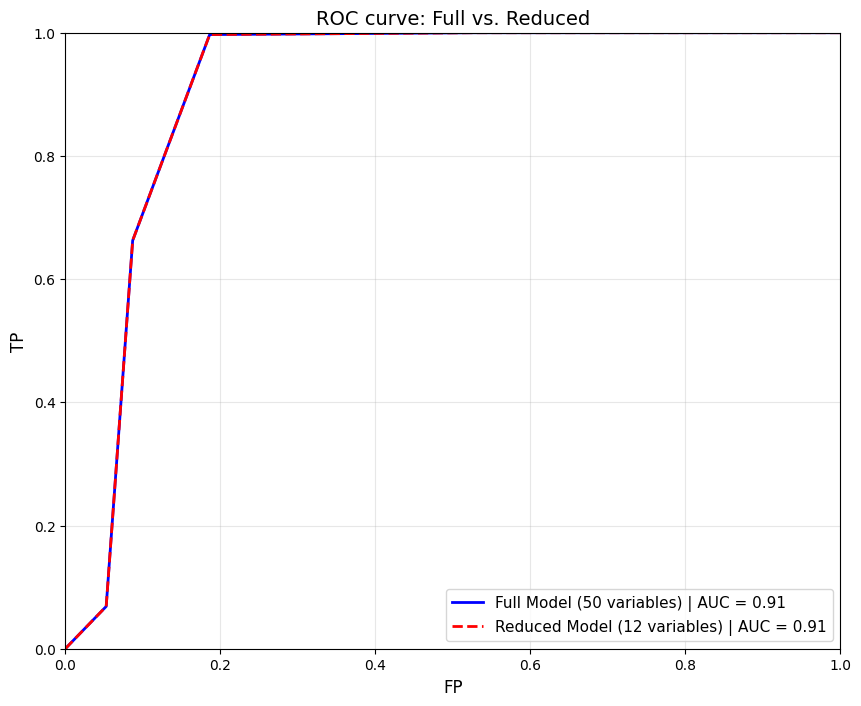

In [48]:
y_prob_full = best_lr.predict_proba(X_test_scaled)[:, 1]
y_prob_reduced = best_lr_reduced.predict_proba(X_test_sub)[:, 1]

# Caculate the FP and TP
fp_full, tp_full, _ = roc_curve(y_test, y_prob_full)
fp_reduced, tp_reduced, _ = roc_curve(y_test, y_prob_reduced)

# Calculate AUC
auc_full = auc(fp_full, tp_full)
auc_reduced = auc(fp_reduced, tp_reduced)

# Plotting
plt.figure(figsize=(10, 8))

# Full model
plt.plot(fp_full, tp_full, color='blue', lw=2,
         label=f'Full Model (50 variables) | AUC = {auc_full:.2f}')

# Reduced model
plt.plot(fp_reduced, tp_reduced, color='red', lw=2, linestyle='--',
         label=f'Reduced Model (12 variables) | AUC = {auc_reduced:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('FP', fontsize=12)
plt.ylabel('TP', fontsize=12)
plt.title('ROC curve: Full vs. Reduced', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)

plt.show()

Findings:
- Both full and reduced models have the exact same test accuracy and auc score (0.91)
- The reduced model is superior as it achieves the exact same accuracy as the full model while requiring approximately 76% less data collection and processing. It's cheaper, faster and more efficient in reality.